<a href="https://colab.research.google.com/github/nehavelmurugan14-oss/DAA-exp-1-/blob/main/DAA_EXP_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Matrix Dimensions

A1 : 10 x 30
A2 : 30 x 5
A3 : 5 x 60
A4 : 60 x 10

Minimum Scalar Multiplications = 5000
Optimal Parenthesization = ((A1 × A2) × (A3 × A4))

DP Cost Table

              A1        A2        A3        A4
A1             0      1500      4500      5000
A2           ---         0      9000      4500
A3           ---       ---         0      3000
A4           ---       ---       ---         0


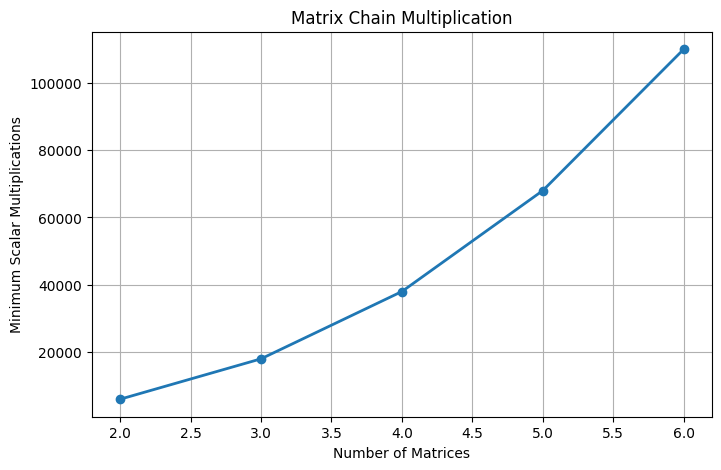

In [1]:
import matplotlib.pyplot as plt

# ---------------- Matrix Chain Multiplication ----------------
def matrix_chain_order(dims):

    n = len(dims) - 1

    m = [[0] * (n + 1) for _ in range(n + 1)]
    s = [[0] * (n + 1) for _ in range(n + 1)]

    for l in range(2, n + 1):

        for i in range(1, n - l + 2):

            j = i + l - 1
            m[i][j] = float('inf')

            for k in range(i, j):

                cost = (m[i][k] +
                        m[k + 1][j] +
                        dims[i - 1] * dims[k] * dims[j])

                if cost < m[i][j]:
                    m[i][j] = cost
                    s[i][j] = k

    return m, s


# ---------------- Print Parenthesization ----------------
def print_optimal_parens(s, i, j):

    if i == j:
        return f"A{i}"

    k = s[i][j]

    left = print_optimal_parens(s, i, k)
    right = print_optimal_parens(s, k + 1, j)

    return f"({left} × {right})"


# ---------------- Print DP Table ----------------
def print_dp_table(m, n):

    print("\nDP Cost Table\n")

    print("{:>6}".format(""), end="")

    for j in range(1, n + 1):
        print("{:>10}".format("A" + str(j)), end="")

    print()

    for i in range(1, n + 1):

        print("{:<6}".format("A" + str(i)), end="")

        for j in range(1, n + 1):

            if j < i:
                print("{:>10}".format("---"), end="")
            else:
                print("{:>10}".format(m[i][j]), end="")

        print()


# ---------------- Example ----------------

dims = [10, 30, 5, 60, 10]

n = len(dims) - 1

print("Matrix Dimensions\n")

for i in range(n):
    print(f"A{i+1} : {dims[i]} x {dims[i+1]}")

m, s = matrix_chain_order(dims)

print("\nMinimum Scalar Multiplications =", m[1][n])

print("Optimal Parenthesization =", print_optimal_parens(s, 1, n))

print_dp_table(m, n)


# ---------------- Performance Analysis ----------------

dimension_sets = [
    [10, 20, 30],
    [10, 20, 30, 40],
    [10, 20, 30, 40, 50],
    [10, 20, 30, 40, 50, 60],
    [10, 20, 30, 40, 50, 60, 70]
]

matrix_count = []
min_cost = []

for dims in dimension_sets:

    matrices = len(dims) - 1

    m, s = matrix_chain_order(dims)

    matrix_count.append(matrices)
    min_cost.append(m[1][matrices])


# ---------------- Graph ----------------

plt.figure(figsize=(8,5))

plt.plot(matrix_count,
         min_cost,
         marker='o',
         linewidth=2)

plt.title("Matrix Chain Multiplication")
plt.xlabel("Number of Matrices")
plt.ylabel("Minimum Scalar Multiplications")
plt.grid(True)

plt.show()